In [ ]:
# Tải dataset
!wget -q https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz
!tar -xzf flower_photos.tgz

# Kiểm tra cấu trúc
!ls flower_photos/
# Sẽ ra: daisy  dandelion  roses  sunflowers  tulips

daisy  dandelion  LICENSE.txt  roses  sunflowers  tulips


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20, width_shift_range=0.15, height_shift_range=0.15,
    zoom_range=0.15, horizontal_flip=True,
    validation_split=0.2  # Tự tách 20% validation
)

train_gen = train_datagen.flow_from_directory(
    'flower_photos', target_size=(128,128), batch_size=32,
    class_mode='categorical', subset='training', shuffle=True)

val_gen = train_datagen.flow_from_directory(
    'flower_photos', target_size=(128,128), batch_size=32,
    class_mode='categorical', subset='validation', shuffle=False)

print(f"Số lớp: {len(train_gen.class_indices)}")
print(f"Labels: {train_gen.class_indices}")

Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.
Số lớp: 5
Labels: {'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


Epoch 1/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 29s 268ms/step - accuracy: 0.3807 - loss: 1.3797 - val_accuracy: 0.4747 - val_loss: 1.2075 - learning_rate: 0.0010
Epoch 2/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 231ms/step - accuracy: 0.4906 - loss: 1.1858 - val_accuracy: 0.5732 - val_loss: 1.1255 - learning_rate: 0.0010
Epoch 3/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 228ms/step - accuracy: 0.5835 - loss: 1.0242 - val_accuracy: 0.5978 - val_loss: 1.0343 - learning_rate: 0.0010
Epoch 4/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 218ms/step - accuracy: 0.6390 - loss: 0.9587 - val_accuracy: 0.6320 - val_loss: 0.9064 - learning_rate: 0.0010
Epoch 5/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - accuracy: 0.6563 - loss: 0.8809 - val_accuracy: 0.6525 - val_loss: 0.8775 - learning_rate: 0.0010
Epoch 6/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 230ms/step - accuracy: 0.6795 - loss: 0.8654 - val_accuracy: 0.6389 - val_loss: 0.8938 - learning_rate: 0.0010
Epoch 7/25
92/92 ━━━━━━━━━━━━━━━━━━━━ 40s 225ms/step - accuracy: 0.7033 - loss: 0.

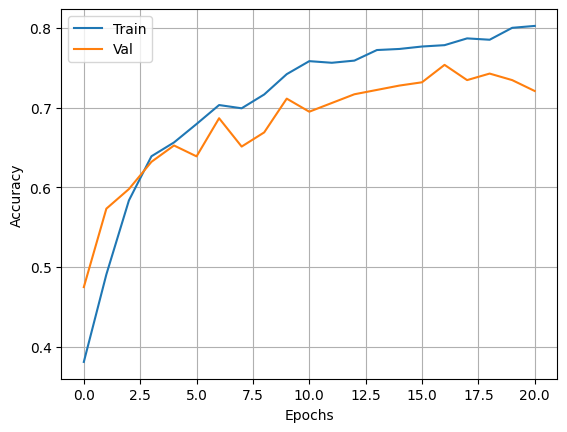

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# 1. Model từ scratch (đã kiểm chứng chạy tốt nhất)
model_final = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (3,3), activation='relu'), MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'), MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'), MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'), Dropout(0.4),
    Dense(128, activation='relu'), Dropout(0.3),
    Dense(5, activation='softmax')
])

model_final.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

# 2. Callbacks tự động
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
lr_reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

# 3. Train
history = model_final.fit(train_gen,
                          validation_data=val_gen,
                          epochs=25,
                          callbacks=[early_stop, lr_reduce],
                          verbose=1)

# 4. Vẽ & Lưu
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend(); plt.grid()
plt.show()

In [ ]:
# 1. LƯU MODEL & LABEL MAP
import json
model_final.save('/content/model_flower_final.h5')
with open('/content/class_map_flower.json', 'w') as f:
    json.dump(train_gen.class_indices, f)
print("✅ Đã lưu model_flower_final.h5 & class_map_flower.json")

✅ Đã lưu model_flower_final.h5 & class_map_flower.json


In [ ]:
# 2. TEST NHANH 1 ẢNH BẤT KỲ
import numpy as np, os, random
from tensorflow.keras.utils import load_img, img_to_array
with open('/content/class_map_flower.json') as f:
    idx_to_label = {v: k for k, v in json.load(f).items()}
test_path = random.choice([os.path.join(r, f) for r, d, fs in os.walk('/content/flower_photos/') for f in fs])
img = load_img(test_path, target_size=(128,128))
pred = idx_to_label[np.argmax(model_final.predict(np.expand_dims(img_to_array(img)/255, 0), verbose=0))]
print(f"📸 Ảnh: {test_path.split('/')[-1]}")
print(f"🔮 Dự đoán: {pred}")

📸 Ảnh: 3502251824_3be758edc6_m.jpg
🔮 Dự đoán: tulips


In [ ]:
import os
import shutil
from google.colab import drive

# Drive đã mount rồi, không cần mount lại
# Tạo thư mục đích (nếu chưa có sẽ tự tạo)
backup_dir = '/content/drive/MyDrive/BTL_AI/Bai2_Hoa'
os.makedirs(backup_dir, exist_ok=True)

# Copy file bằng shutil (ổn định hơn !cp)
shutil.copy('/content/model_flower_final.h5', backup_dir)
shutil.copy('/content/class_map_flower.json', backup_dir)

print(f"✅ Đã backup thành công vào: {backup_dir}")
print("📁 Kiểm tra file:")
for f in os.listdir(backup_dir):
    print(f"  • {f}")

✅ Đã backup thành công vào: /content/drive/MyDrive/BTL_AI/Bai2_Hoa
📁 Kiểm tra file:
  • model_flower_final.h5
  • class_map_flower.json


In [2]:
from google.colab import drive
import tensorflow as tf
import json, numpy as np, os

# 1. Mount Drive (sẽ yêu cầu xác minh 1 lần duy nhất)
drive.mount('/content/drive')

# 2. Chỉnh lại đường dẫn nếu lưu chỗ khác
MODEL_PATH = '/content/drive/MyDrive/BTL_AI/Bai2_Hoa/model_flower_final.h5'
MAP_PATH   = '/content/drive/MyDrive/BTL_AI/Bai2_Hoa/class_map_flower.json'

# Kiểm tra file tồn tại không
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"❌ Không tìm thấy model tại: {MODEL_PATH}\n👉 Kiểm tra lại đường dẫn trên Drive")

# 3. Load model & map nhãn
model = tf.keras.models.load_model(MODEL_PATH)
with open(MAP_PATH, 'r') as f:
    class_map = json.load(f)
idx_to_label = {v: k for k, v in class_map.items()}

print(f"✅ Đã load model thành công!")
print(f"📦 Các lớp có thể nhận dạng: {list(idx_to_label.values())}")

Mounted at /content/drive


✅ Đã load model thành công!
📦 Các lớp có thể nhận dạng: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


Nhập 'u' để upload ảnh từ máy, hoặc dán URL ảnh: https://www.dutchgrown.co.uk/cdn/shop/files/Tulip_Jumbo_Pink-6.jpg?v=1716911564


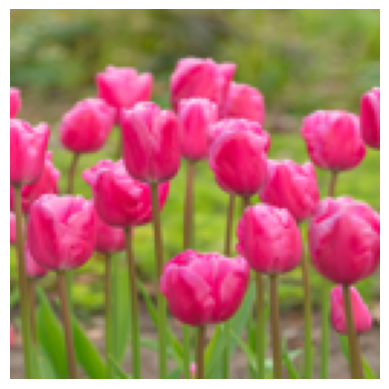

🔮 Dự đoán: tulips
📊 Độ tin cậy: 99.64%
📈 Chi tiết: ['daisy: 0.0%', 'dandelion: 0.0%', 'roses: 0.4%', 'sunflowers: 0.0%', 'tulips: 99.6%']


In [5]:
import requests, matplotlib.pyplot as plt
from tensorflow.keras.utils import img_to_array
from PIL import Image
from io import BytesIO
from google.colab import files

def test_flower():
    choice = input("Nhập 'u' để upload ảnh từ máy, hoặc dán URL ảnh: ").strip()

    if choice.lower() == 'u':
        uploaded = files.upload()
        img_path = list(uploaded.keys())[0]
        img = Image.open(img_path).convert('RGB').resize((128, 128))
    else:
        url = choice if choice.startswith('http') else f"https://{choice}"
        img = Image.open(BytesIO(requests.get(url).content)).convert('RGB').resize((128, 128))

    # Hiển thị ảnh
    plt.imshow(img); plt.axis('off'); plt.show()

    # Dự đoán
    x = img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    pred = model.predict(x, verbose=0)
    idx = np.argmax(pred)
    conf = pred[0][idx] * 100

    print(f"🔮 Dự đoán: {idx_to_label[idx]}")
    print(f"📊 Độ tin cậy: {conf:.2f}%")
    print(f"📈 Chi tiết: {[f'{idx_to_label[i]}: {p*100:.1f}%' for i, p in enumerate(pred[0])]}")

# Chạy test
test_flower()